# EDA: German Electricity Consumption

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/opsd_germany_daily.csv', index_col=0, parse_dates=True)
df.head()

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184,NaN,NaN,NaN
2006-01-02,1380.521,NaN,NaN,NaN
2006-01-03,1442.533,NaN,NaN,NaN
2006-01-04,1457.217,NaN,NaN,NaN
2006-01-05,1477.131,NaN,NaN,NaN


In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(4383, 4)
Consumption    float64
Wind           float64
Solar          float64
Wind+Solar     float64
dtype: object
Consumption       0
Wind           1463
Solar          2195
Wind+Solar     2196
dtype: int64


In [3]:
print(f"Date range: {df.index.min()} to {df.index.max()}")
print()
print(df['Consumption'].describe())

Date range: 2006-01-01 00:00:00 to 2017-12-31 00:00:00

count    4383.000000
mean     1338.675836
std       165.775710
min       842.395000
25%      1217.859000
50%      1367.123000
75%      1457.761000
max      1709.568000
Name: Consumption, dtype: float64


## Consumption over time

Strong seasonal pattern as expected : Germany runs significantly higher consumption in winter. 
The weekly rhythm is also visible. 
Some isolated sharp drops are probably public holidays (Christmas etc).

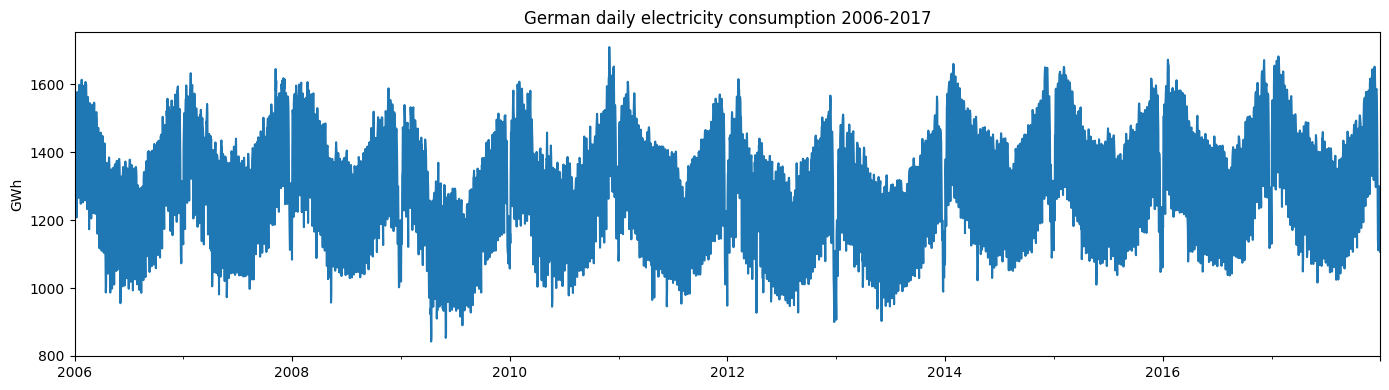

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
df['Consumption'].plot(ax=ax)
ax.set_title('German daily electricity consumption 2006-2017')
ax.set_ylabel('GWh')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## Weekly pattern

Weekdays are pretty flat around 1400 GWh, then it drops off on Saturday and Sunday. 
Sunday is the lowest. 

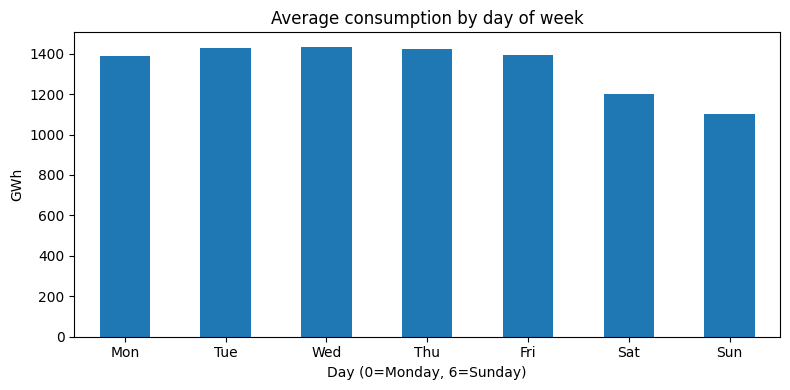

In [5]:
df['dayofweek'] = df.index.dayofweek

fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('dayofweek')['Consumption'].mean().plot(kind='bar', ax=ax)
ax.set_title('Average consumption by day of week')
ax.set_xlabel('Day (0=Monday, 6=Sunday)')
ax.set_ylabel('GWh')
ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
plt.tight_layout()
plt.show()

## Monthly pattern

Winter months (Jan/Feb) are highest, summer (Aug) lowest, but only about 200 GWh difference. December is lower than Jan/Feb, probably holiday shutdowns.

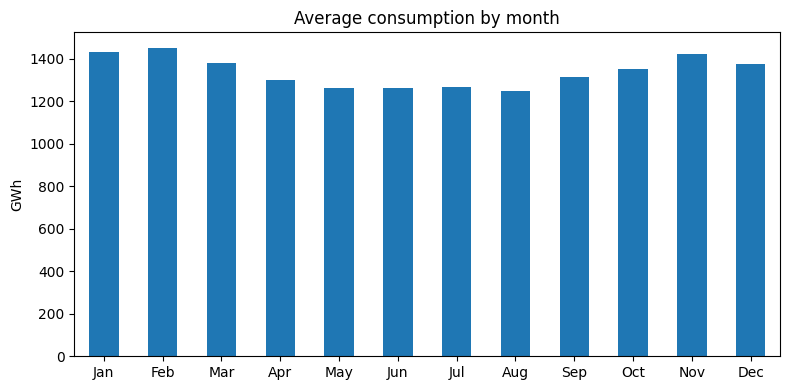

In [6]:
df['month'] = df.index.month

fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('month')['Consumption'].mean().plot(kind='bar', ax=ax)
ax.set_title('Average consumption by month')
ax.set_xlabel('')
ax.set_ylabel('GWh')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()

## Feature Engineering

Adding time-based and lag features for the forecasting models.

In [7]:
# create a clean copy for modelling
data = df[['Consumption']].copy()

# time features
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month
data['is_weekend'] = (data.index.dayofweek >= 5).astype(int)

# lag features — yesterday and last week
data['lag_1'] = data['Consumption'].shift(1)
data['lag_7'] = data['Consumption'].shift(7)

# rolling average — last 7 days
data['rolling_7'] = data['Consumption'].shift(1).rolling(7).mean()

# drop rows with NaN from lag/rolling
data = data.dropna()

print(data.shape)
data.head()

(4376, 7)


,Consumption,dayofweek,month,is_weekend,lag_1,lag_7,rolling_7
Date,,,,,,,
2006-01-08,1207.985,6,1,1,1300.287,1069.184,1361.471429
2006-01-09,1529.323,0,1,0,1207.985,1380.521,1381.300143
2006-01-10,1576.911,1,1,0,1529.323,1442.533,1402.557571
2006-01-11,1577.176,2,1,0,1576.911,1457.217,1421.754429
2006-01-12,1553.280,3,1,0,1577.176,1477.131,1438.891429


In [8]:
# use last year (2017) as test set, everything before as training
train = data[data.index.year < 2017]
test = data[data.index.year == 2017]

print(f"Train: {train.shape[0]} rows ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {test.shape[0]} rows ({test.index.min().date()} to {test.index.max().date()})")

Train: 4011 rows (2006-01-08 to 2016-12-31)
Test:  365 rows (2017-01-01 to 2017-12-31)


In [9]:
features = ['dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_7', 'rolling_7']
target = 'Consumption'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print(X_train.shape, X_test.shape)

(4011, 6) (365, 6)


## Baseline Model: Day-of-week weighted average 
Predict consumption as weighted average of last n same-weekdays.
Recent weeks get higher weight.

In [23]:
def dow_average_baseline(train, test, n_weeks=5, decay=0.85):
    predictions = []
    
    for date, row in test.iterrows():
        dow = date.dayofweek
        month = date.month
        
        # get same weekday AND same month from training
        same_dow_month = train[
            (train.index.dayofweek == dow) & 
            (train.index.month == month)
        ]
        
        # take last n occurrences
        last_n = same_dow_month.iloc[-n_weeks:]
        
        # exponential weights — most recent gets highest weight
        weights = np.array([decay ** i for i in range(len(last_n)-1, -1, -1)])
        weights = weights / weights.sum()
        
        pred = np.average(last_n['Consumption'].values, weights=weights)
        predictions.append(pred)
    
    return np.array(predictions)

dow_pred = dow_average_baseline(train, test)

mae_dow = mean_absolute_error(y_test, dow_pred)
rmse_dow = np.sqrt(mean_squared_error(y_test, dow_pred))

print(f"Day-of-week baseline — MAE: {mae_dow:.2f}, RMSE: {rmse_dow:.2f}")

Day-of-week baseline — MAE: 46.31, RMSE: 75.29


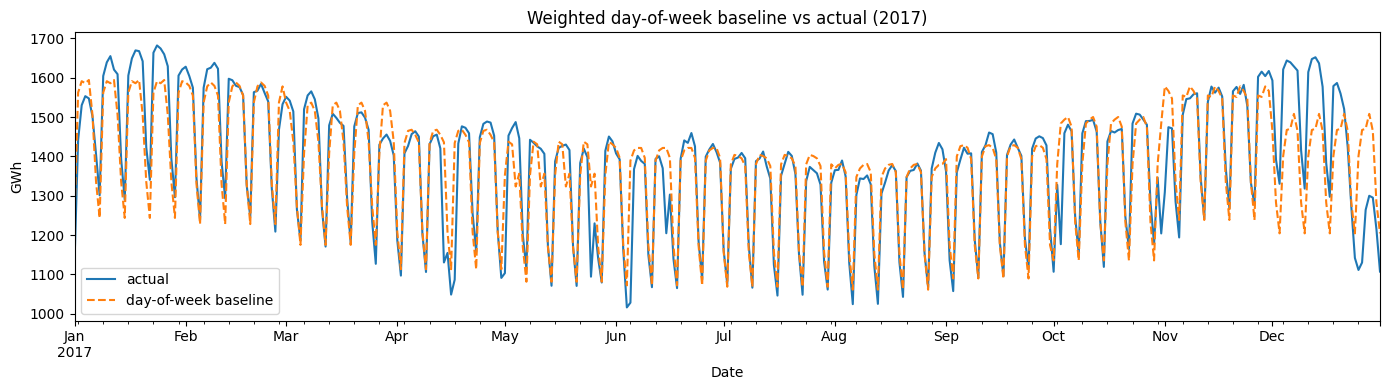

In [24]:
fig, ax = plt.subplots(figsize=(14, 4))
y_test.plot(ax=ax, label='actual')
pd.Series(dow_pred, index=y_test.index).plot(ax=ax, label='day-of-week baseline', linestyle='--')
ax.set_title('Weighted day-of-week baseline vs actual (2017)')
ax.set_ylabel('GWh')
ax.legend()
plt.tight_layout()
plt.show()

## Model 2: KNN

K-Nearest Neighbours : finds the most similar historical days and averages their consumption.
Similar logic to the baseline but learns from all features together rather than rules.

In [25]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# scale features — KNN is distance-based so scaling matters
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train KNN
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test, knn_pred)
rmse_knn = np.sqrt(mean_squared_error(y_test, knn_pred))

print(f"KNN — MAE: {mae_knn:.2f}, RMSE: {rmse_knn:.2f}")

KNN — MAE: 29.25, RMSE: 50.86


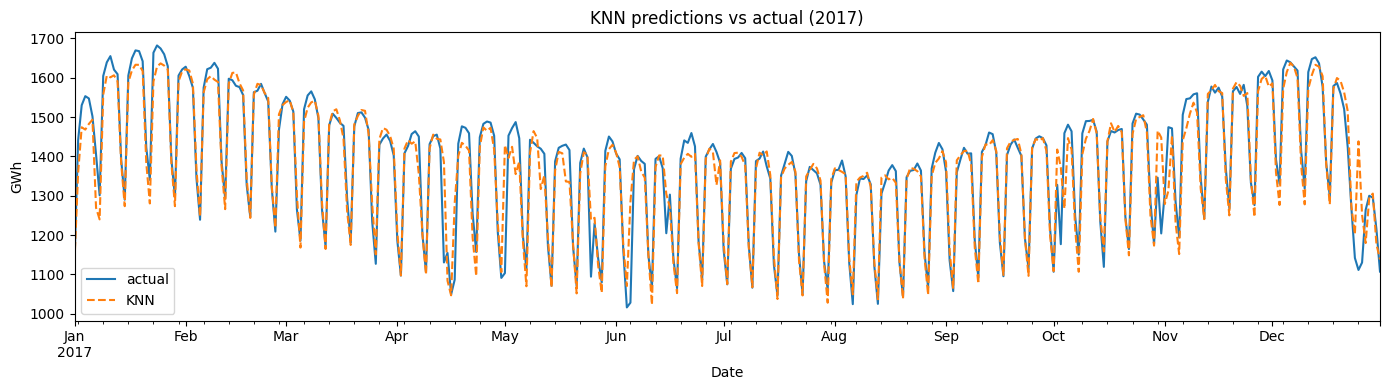

In [26]:
fig, ax = plt.subplots(figsize=(14, 4))
y_test.plot(ax=ax, label='actual')
pd.Series(knn_pred, index=y_test.index).plot(ax=ax, label='KNN', linestyle='--')
ax.set_title('KNN predictions vs actual (2017)')
ax.set_ylabel('GWh')
ax.legend()
plt.tight_layout()
plt.show()

 ## KNN results

MAE: 29 GWh, RMSE: 51 GWh. 

Clear improvement over the baseline. 

The weekly and seasonal patterns are both captured well. Main weakness is the sharp 
holiday dips which the model can't anticipate without explicit holiday features.

## Model 3: MLP (Neural Network)

Simple feedforward neural network: two hidden layers. 
Should pick up non-linear interactions between features that KNN might miss.


In [27]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

mlp_pred = mlp.predict(X_test_scaled)

mae_mlp = mean_absolute_error(y_test, mlp_pred)
rmse_mlp = np.sqrt(mean_squared_error(y_test, mlp_pred))

print(f"MLP — MAE: {mae_mlp:.2f}, RMSE: {rmse_mlp:.2f}")

MLP — MAE: 27.21, RMSE: 51.89


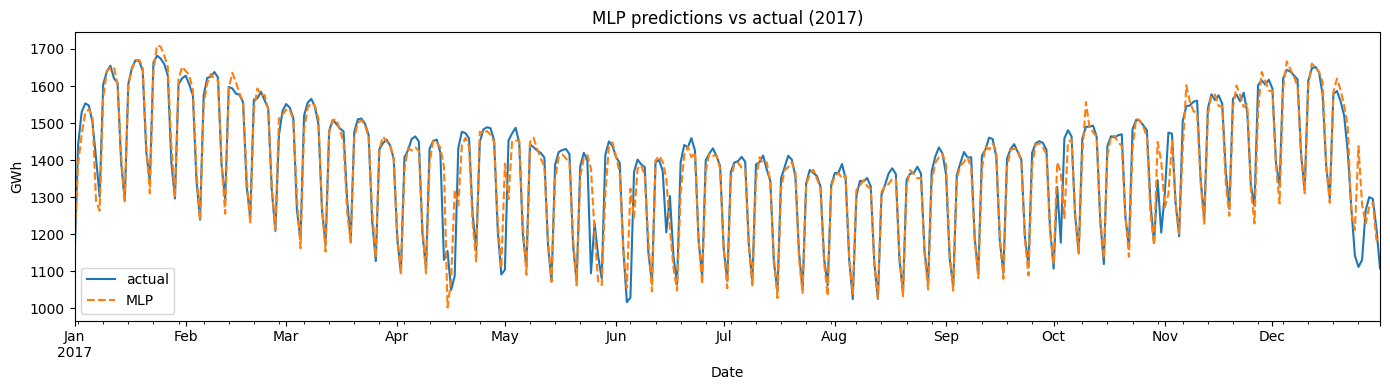

In [28]:
fig, ax = plt.subplots(figsize=(14, 4))
y_test.plot(ax=ax, label='actual')
pd.Series(mlp_pred, index=y_test.index).plot(ax=ax, label='MLP', linestyle='--')
ax.set_title('MLP predictions vs actual (2017)')
ax.set_ylabel('GWh')
ax.legend()
plt.tight_layout()
plt.show()

## MLP results

MAE: 27 GWh, RMSE: 52 GWh. Marginally better than KNN on MAE but almost identical 
overall. With only 6 features there's not much room for the neural network to find 
additional non-linear patterns beyond what KNN already captures. Both models struggle 
on sharp holiday dips, expected without explicit holiday features.

## Model comparison

                        MAE   RMSE
Day-of-week baseline  46.31  75.29
KNN                   29.25  50.86
MLP                   27.21  51.89


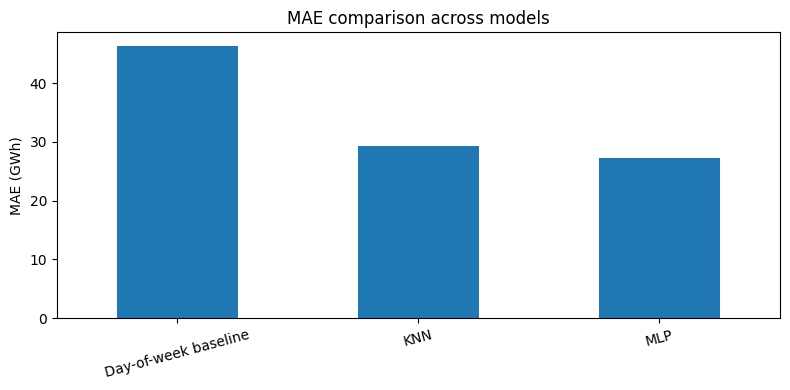

In [29]:
results = {
    'Day-of-week baseline': {'MAE': mae_dow, 'RMSE': rmse_dow},
    'KNN': {'MAE': mae_knn, 'RMSE': rmse_knn},
    'MLP': {'MAE': mae_mlp, 'RMSE': rmse_mlp}
}

results_df = pd.DataFrame(results).T
print(results_df.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
results_df['MAE'].plot(kind='bar', ax=ax)
ax.set_title('MAE comparison across models')
ax.set_ylabel('MAE (GWh)')
ax.set_xticklabels(results_df.index, rotation=15)
plt.tight_layout()
plt.show()

## Conclusion

Tested all three models on 2017 data (365 days).

| Model | MAE | RMSE |
|-------|-----|------|
| Day-of-week baseline | 46 GWh | 75 GWh |
| KNN | 29 GWh | 51 GWh |
| MLP | 27 GWh | 52 GWh |

Both ML models beat the baseline by a decent margin. I think the lag features are doing 
most of the work here — yesterday's actual consumption is a strong signal that the 
baseline simply doesn't use.

KNN and MLP end up pretty close to each other. Adding weather or holiday data would 
probably move the needle more than switching to a more complex model.